# Car Price Prediction with Machine Learning

## Objective

Build a machine learning regression model to predict the selling price of a used car based on features such as brand, age, mileage, fuel type, and transmission.

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df=pd.read_csv("car_prediction_data.csv")
df

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [68]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [69]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')

In [70]:
df.Car_Name

0         ritz
1          sx4
2         ciaz
3      wagon r
4        swift
        ...   
296       city
297       brio
298       city
299       city
300       brio
Name: Car_Name, Length: 301, dtype: object

In [71]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [72]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [73]:
print("Shape",df.shape)

Shape (301, 9)


In [74]:
df.drop_duplicates()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [75]:
df.duplicated().sum()

np.int64(2)

In [76]:
df=df.drop_duplicates()

In [77]:
df.duplicated().sum()

np.int64(0)

In [78]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [79]:
df

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [80]:
print("Fuel_Type")
print(df["Fuel_Type"].unique())

Fuel_Type
['Petrol' 'Diesel' 'CNG']


In [81]:
print("Seller_Type")
print(df["Seller_Type"].unique())

print("\n Selling_price")
print(df["Selling_Price"].unique())

Seller_Type
['Dealer' 'Individual']

 Selling_price
[ 3.35  4.75  7.25  2.85  4.6   9.25  6.75  6.5   8.75  7.45  6.85  7.5
  6.1   2.25  7.75  3.25  2.65  4.9   4.4   2.5   2.9   3.    4.15  6.
  1.95  3.1   2.35  4.95  5.5   2.95  4.65  0.35  5.85  2.55  1.25  1.05
  5.8  14.9  23.   18.   16.    2.75  3.6   4.5   4.1  19.99  6.95 18.75
 23.5  33.   19.75  4.35 14.25  3.95  1.5   5.25 14.5  14.73 12.5   3.49
 35.    5.9   3.45  3.8  11.25  3.51  4.   20.75 17.    7.05  9.65  1.75
  1.7   1.65  1.45  1.35  1.2   1.15  1.11  1.1   1.    0.95  0.9   0.75
  0.8   0.78  0.72  0.65  0.6   0.55  0.52  0.51  0.5   0.48  0.45  0.42
  0.4   0.38  0.31  0.3   0.27  0.25  0.2   0.18  0.17  0.16  0.15  0.12
  0.1   5.75  5.15  7.9   4.85 11.75  3.15  6.45  3.5   8.25  5.11  2.7
  6.15 11.45  3.9   9.1   4.8   2.    5.35  6.25  5.95  5.2   3.75 12.9
  5.    5.4   7.2  10.25  8.5   8.4   9.15  6.6   3.65  8.35  6.7   5.3
 10.9   8.65  9.7   2.1   8.99  7.4   5.65 10.11  6.4   8.55  9.5  11.5 ]


In [82]:
# Remove extra spaces and standardize categorical values
df["Fuel_Type"] = df["Fuel_Type"].str.strip().str.title()
df["Seller_Type"] = df["Seller_Type"].str.strip().str.title()
df["Transmission"] = df["Transmission"].str.strip().str.title()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_21832\3280781715.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Fuel_Type"] = df["Fuel_Type"].str.strip().str.title()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_21832\3280781715.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Seller_Type"] = df["Seller_Type"].str.strip().str.title()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_21832\3280781715.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using 

In [83]:
print(df["Fuel_Type"].unique())
print(df["Seller_Type"].unique())
print(df["Transmission"].unique())

['Petrol' 'Diesel' 'Cng']
['Dealer' 'Individual']
['Manual' 'Automatic']


In [84]:
# Create Car Age
current_year = 2026
df["Car_Age"] = current_year - df["Year"]

# Extract Brand from Car Name
df["Brand"] = df["Car_Name"].str.split().str[0]

# Check new columns
print(df[["Car_Name", "Year", "Car_Age", "Brand"]].head())

  Car_Name  Year  Car_Age  Brand
0     ritz  2014       12   ritz
1      sx4  2013       13    sx4
2     ciaz  2017        9   ciaz
3  wagon r  2011       15  wagon
4    swift  2014       12  swift


C:\Users\ASUS\AppData\Local\Temp\ipykernel_21832\4157551782.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Car_Age"] = current_year - df["Year"]
C:\Users\ASUS\AppData\Local\Temp\ipykernel_21832\4157551782.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Brand"] = df["Car_Name"].str.split().str[0]


In [85]:
print(df.columns)

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner', 'Car_Age',
       'Brand'],
      dtype='object')


In [86]:
df.columns.tolist()

['Car_Name',
 'Year',
 'Selling_Price',
 'Present_Price',
 'Kms_Driven',
 'Fuel_Type',
 'Seller_Type',
 'Transmission',
 'Owner',
 'Car_Age',
 'Brand']

In [87]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age,Brand
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12,ritz
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13,sx4
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9,ciaz
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15,wagon
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12,swift


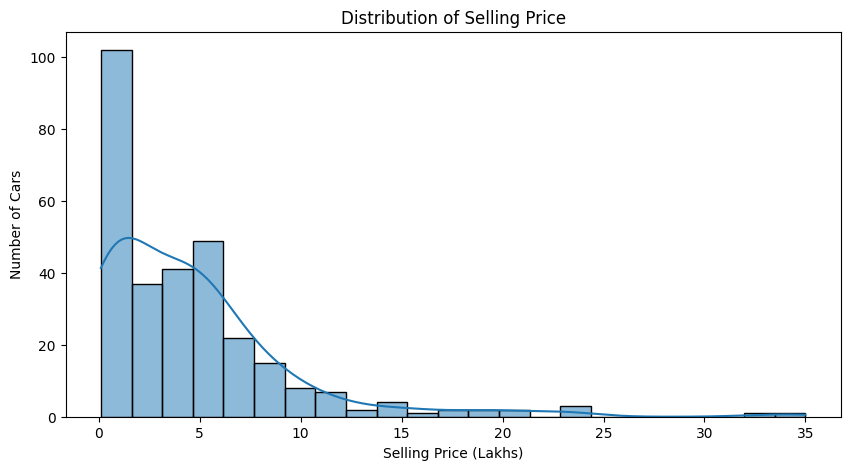

In [88]:
plt.figure(figsize=(10, 5))

sns.histplot(df["Selling_Price"], kde=True)

plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price (Lakhs)")
plt.ylabel("Number of Cars")

plt.show()

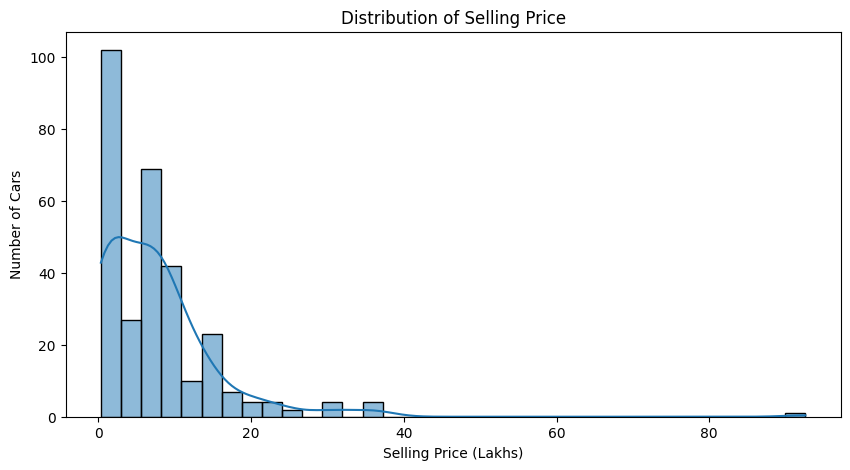

In [89]:
plt.figure(figsize=(10, 5))

sns.histplot(df["Present_Price"], kde=True)

plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price (Lakhs)")
plt.ylabel("Number of Cars")

plt.show()

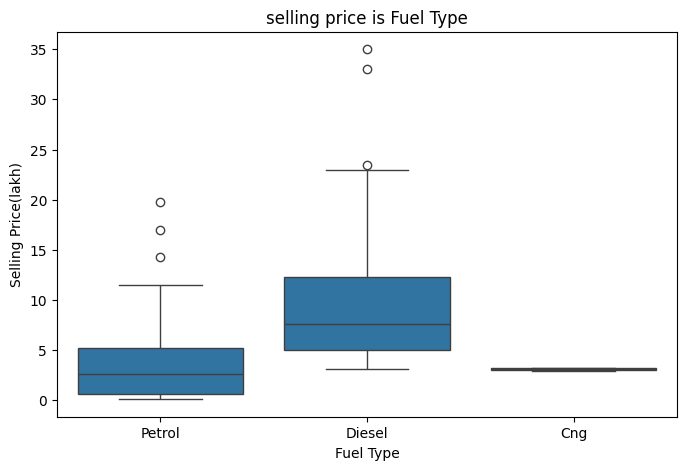

In [90]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data = df, 
    x="Fuel_Type",
    y="Selling_Price"
)
plt.title("selling price is Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price(lakh)")
plt.show()

### Observation

The box plot shows the distribution of selling prices across different fuel types. Petrol cars are more common in the dataset, while diesel and CNG cars show different price distributions.

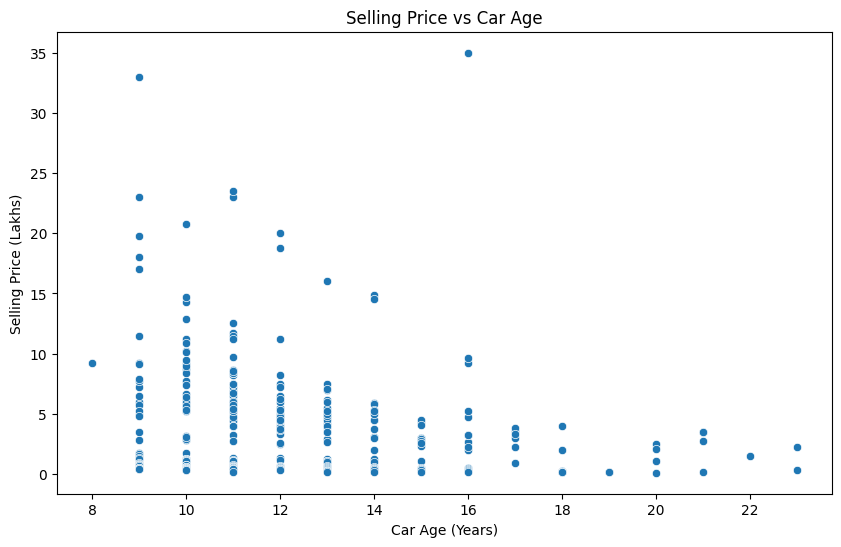

In [91]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Car_Age",
    y="Selling_Price"
)

plt.title("Selling Price vs Car Age")
plt.xlabel("Car Age (Years)")
plt.ylabel("Selling Price (Lakhs)")

plt.show()

### Observation

The scatter plot shows the relationship between car age and selling price. In general, older cars tend to have lower selling prices, while newer cars usually have higher selling prices. However, some variation can be observed depending on other factors such as brand, mileage, and condition.

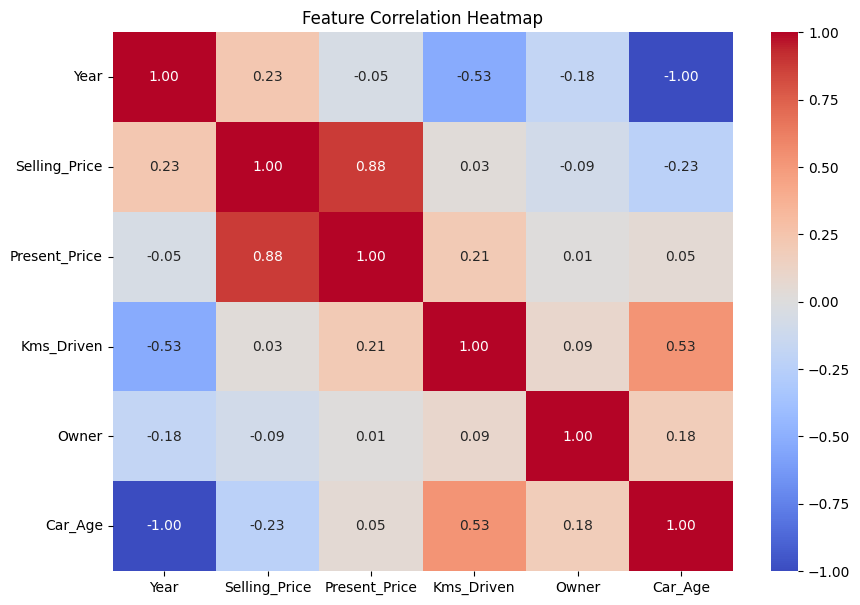

In [92]:
plt.figure(figsize=(10, 7))

numeric_data = df[
    [
        "Year",
        "Selling_Price",
        "Present_Price",
        "Kms_Driven",
        "Owner",
        "Car_Age"
    ]
]

correlation = numeric_data.corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")
plt.show()

### Observation

The correlation heatmap shows the relationships between the numerical features. Selling price has a strong positive relationship with present price, while car age generally has a negative relationship with selling price. This indicates that newer cars tend to have higher selling prices.

In [94]:
y = df["Selling_Price"]

X = df.drop(columns=["Selling_Price", "Car_Name"])

In [95]:
# Convert categorical columns into numerical columns
X = pd.get_dummies(
    X,
    columns=["Fuel_Type", "Seller_Type", "Transmission", "Brand"],
    drop_first=True
)

X.head()

,Year,Present_Price,Kms_Driven,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual,Brand_Activa,...,Brand_land,Brand_omni,Brand_ritz,Brand_s,Brand_swift,Brand_sx4,Brand_verna,Brand_vitara,Brand_wagon,Brand_xcent
0,2014,5.59,27000,0,12,False,True,False,True,False,...,False,False,True,False,False,False,False,False,False,False
1,2013,9.54,43000,0,13,True,False,False,True,False,...,False,False,False,False,False,True,False,False,False,False
2,2017,9.85,6900,0,9,False,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,2011,4.15,5200,0,15,False,True,False,True,False,...,False,False,False,False,False,False,False,False,True,False
4,2014,6.87,42450,0,12,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False


In [96]:
print("Feature shape:", X.shape)
print(X.dtypes)

Feature shape: (299, 52)
Year                        int64
Present_Price             float64
Kms_Driven                  int64
Owner                       int64
Car_Age                     int64
Fuel_Type_Diesel             bool
Fuel_Type_Petrol             bool
Seller_Type_Individual       bool
Transmission_Manual          bool
Brand_Activa                 bool
Brand_Bajaj                  bool
Brand_Hero                   bool
Brand_Honda                  bool
Brand_Hyosung                bool
Brand_KTM                    bool
Brand_Mahindra               bool
Brand_Royal                  bool
Brand_Suzuki                 bool
Brand_TVS                    bool
Brand_UM                     bool
Brand_Yamaha                 bool
Brand_alto                   bool
Brand_amaze                  bool
Brand_baleno                 bool
Brand_brio                   bool
Brand_camry                  bool
Brand_ciaz                   bool
Brand_city                   bool
Brand_corolla          

## Categorical Variable Encoding

Categorical features such as fuel type, seller type, 
transmission, and brand were converted into numerical variables using One-Hot Encoding. 
The target variable is the Selling Price.

In [98]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (239, 52)
Testing data: (60, 52)


## Train-Test Split

The dataset was divided into training and testing sets using an 80:20 ratio. The training set is used to train the regression models, while the testing set is used to evaluate their performance on unseen data.

In [99]:
from sklearn.linear_model import LinearRegression

# Create model
lr_model = LinearRegression()

# Train model
lr_model.fit(X_train, y_train)

# Predict
lr_pred = lr_model.predict(X_test)

In [100]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R² Score:", lr_r2)

Linear Regression
MAE : 1.8087830243640972
RMSE: 3.399320577163627
R² Score: 0.5516523951568391


In [101]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

# Predict
rf_pred = rf_model.predict(X_test)

In [102]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Regressor")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

Random Forest Regressor
MAE : 1.4087566666666664
RMSE: 3.429491782016204
R² Score: 0.5436583160677366


In [103]:
# Compare the models 

In [104]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R² Score": [lr_r2, rf_r2]
})

comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,1.808783,3.399321,0.551652
1,Random Forest,1.408757,3.429492,0.543658


## Model Comparison and Best Model

Two regression models were trained and evaluated: Linear Regression and Random Forest Regressor.

Random Forest achieved the lowest Mean Absolute Error (MAE) of 1.41, indicating that its average prediction error was lower than Linear Regression. Although Linear Regression achieved slightly better RMSE and R² scores, Random Forest was selected as the final model based on its lower MAE and ability to capture non-linear relationships in the data.

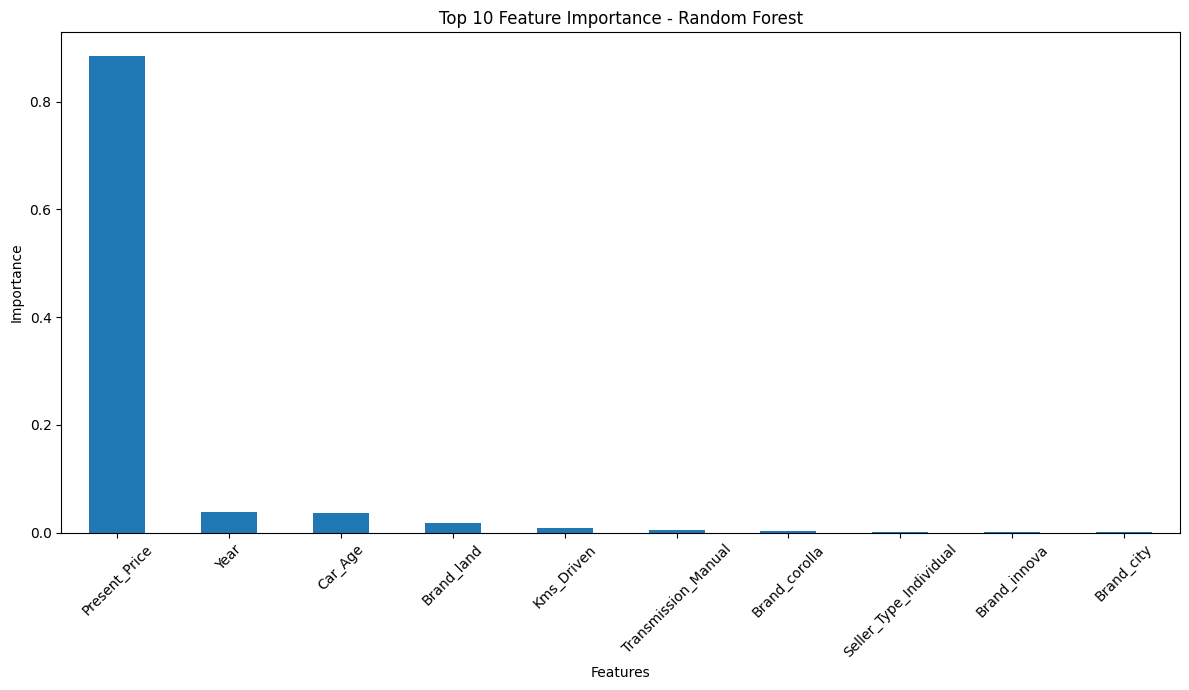

In [105]:
# Feature importance from Random Forest
importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(12, 7))

importance.head(10).plot(kind="bar")

plt.title("Top 10 Feature Importance - Random Forest")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

The feature importance chart shows which features contributed most to the Random Forest model's predictions. Features with higher importance have a greater influence on predicting the selling price of used cars.

## Conclusion

This project developed a machine learning regression system to predict the selling price of used cars. The dataset was cleaned and processed, followed by feature engineering, exploratory data analysis, categorical encoding, and model training.

Two regression models, Linear Regression and Random Forest Regressor, were trained and evaluated using MAE, RMSE, and R² score. Random Forest achieved the lowest MAE and was selected as the final model. Feature importance analysis was also performed to understand which variables contributed most to the predictions.